ADVANCED ANALYTICS

Stastical Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Amazon dataset

df = pd.read_csv("processed_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (128975, 24)


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship,False
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,Easy Ship,False
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship,False
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship,False


In [3]:
# Basic dataset inspection

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(128975, 24)

Column Names:
['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']

Data Types:
index                   int64
Order ID               object
Date                   object
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Style                  object
SKU                    object
Category               object
Size                   object
ASIN                   object
Courier Status         object
Qty                     int64
currency               object
Amount                float64
ship-city              object
ship-state             object
ship-postal-code      float64
ship-country           object
promotion-ids          object
B2B        

data cleaning

In [4]:
# Remove unnecessary columns

columns_to_drop = [
    'index',
    'Unnamed: 22'
]

df = df.drop(
    columns=[col for col in columns_to_drop if col in df.columns],
    errors='ignore'
)

# Remove duplicate rows
df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (128969, 22)


convert data types 

# Convert Date to datetime
df['Date'] = pd.to_datetime(
    df['Date'],
    errors='coerce'
)

# Convert Qty and Amount to numeric
df['Qty'] = pd.to_numeric(
    df['Qty'],
    errors='coerce'
)

df['Amount'] = pd.to_numeric(
    df['Amount'],
    errors='coerce'
)

print(df[['Date', 'Qty', 'Amount']].dtypes)

In [5]:
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill numeric missing values with median
df['Qty'] = df['Qty'].fillna(df['Qty'].median())
df['Amount'] = df['Amount'].fillna(df['Amount'].median())

# Fill categorical missing values
categorical_columns = [
    'Status',
    'Category',
    'Fulfilment',
    'Sales Channel'
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier Status        0
Qty                   0
currency              0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
promotion-ids         0
B2B                   0
fulfilled-by          0
dtype: int64

Missing values after cleaning:
Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier Status        0
Qty                   0
currency              0
Amount                0
ship-city             0
ship-state 

descriptive Stastical analysis

In [6]:
# Select important numerical columns
numeric_columns = ['Qty', 'Amount']

for col in numeric_columns:
    print("\n==============================")
    print("Statistics for:", col)
    print("==============================")
    
    print("Mean   :", df[col].mean())
    print("Median :", df[col].median())
    print("Mode   :", df[col].mode()[0])


Statistics for: Qty
Mean   : 0.9044499065666943
Median : 1.0
Mode   : 1

Statistics for: Amount
Mean   : 645.9242399336275
Median : 605.0
Mode   : 605.0


In [7]:
for col in numeric_columns:
    print("\n==============================")
    print("Analysis for:", col)
    print("==============================")
    
    print("Standard Deviation:", df[col].std())
    print("Skewness:", df[col].skew())


Analysis for: Qty
Standard Deviation: 0.3133301726395119
Skewness: -0.6974880046999974

Analysis for: Amount
Standard Deviation: 272.77990052082686
Skewness: 0.9402621148156508


In [8]:
df[numeric_columns].describe()

,Qty,Amount
count,128969.00000,128969.000000
mean,0.90445,645.924240
std,0.31333,272.779901
min,0.00000,0.000000
25%,1.00000,459.000000
50%,1.00000,605.000000
75%,1.00000,771.000000
max,15.00000,5584.000000


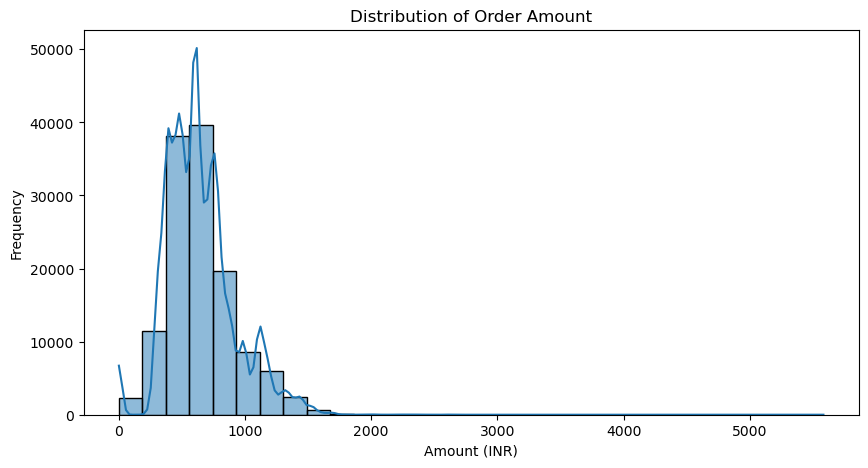

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(df['Amount'], bins=30, kde=True)

plt.title("Distribution of Order Amount")
plt.xlabel("Amount (INR)")
plt.ylabel("Frequency")

plt.show()

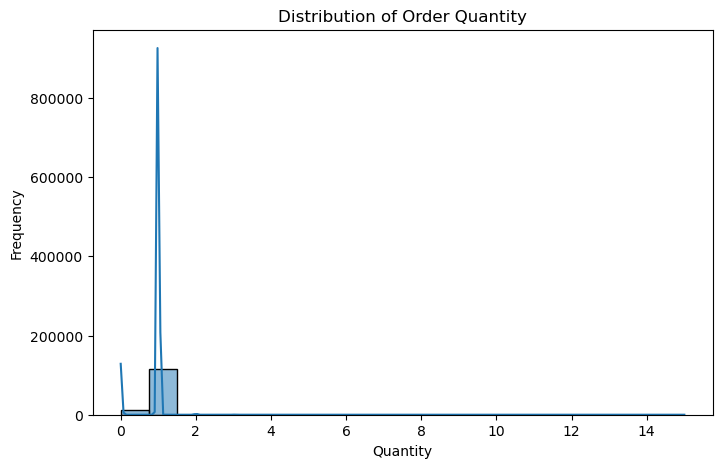

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Qty'], bins=20, kde=True)

plt.title("Distribution of Order Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

In [11]:
# Check fulfilment categories
print(df['Fulfilment'].value_counts())

Fulfilment
Amazon      89692
Merchant    39277
Name: count, dtype: int64


In [12]:
# Separate order amounts by fulfilment type

amazon_orders = df[
    df['Fulfilment'].astype(str).str.lower() == 'amazon'
]['Amount']

merchant_orders = df[
    df['Fulfilment'].astype(str).str.lower() == 'merchant'
]['Amount']

print("Amazon orders:", len(amazon_orders))
print("Merchant orders:", len(merchant_orders))

Amazon orders: 89692
Merchant orders: 39277


In [13]:
t_stat, p_value = stats.ttest_ind(
    amazon_orders,
    merchant_orders,
    equal_var=False,
    nan_policy='omit'
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nResult: Reject the null hypothesis.")
    print("There is a statistically significant difference in order amounts.")
else:
    print("\nResult: Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in order amounts.")

T-statistic: 1.0879708666597112
P-value: 0.27661148729992935

Result: Fail to reject the null hypothesis.
There is no statistically significant difference in order amounts.


In [14]:
# Create contingency table

contingency_table = pd.crosstab(
    df['Category'],
    df['Status']
)

print(contingency_table)

Status         Cancelled  Pending  Pending - Waiting for Pick Up  Shipped  \
Category                                                                    
Blouse               116        3                              1      623   
Bottom                60        1                              2      222   
Dupatta                0        0                              0        3   
Ethnic Dress         145        7                              0      755   
Saree                 21        0                              0      119   
Set                 7336      252                            108    30663   
Top                 1276       55                             19     7143   
Western Dress       2122       92                             79     7480   
kurta               7253      248                             72    30793   

Status         Shipped - Damaged  Shipped - Delivered to Buyer  \
Category                                                         
Blouse              

In [15]:
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nResult: Reject the null hypothesis.")
    print("Category and Status are significantly associated.")
else:
    print("\nResult: Fail to reject the null hypothesis.")
    print("No significant association was detected.")

Chi-square statistic: 1867.8546255419772
Degrees of freedom: 96
P-value: 0.0

Result: Reject the null hypothesis.
Category and Status are significantly associated.


In [16]:
amount = df['Amount'].dropna()

mean_amount = amount.mean()
std_amount = amount.std()
n = len(amount)

confidence = 0.95

standard_error = std_amount / np.sqrt(n)

margin_error = stats.t.ppf(
    (1 + confidence) / 2,
    df=n-1
) * standard_error

lower = mean_amount - margin_error
upper = mean_amount + margin_error

print("Mean Order Amount:", mean_amount)
print("95% Confidence Interval:")
print("Lower:", lower)
print("Upper:", upper)

Mean Order Amount: 645.9242399336275
95% Confidence Interval:
Lower: 644.4354896153135
Upper: 647.4129902519416


In [17]:
# Daily sales

daily_sales = df.groupby('Date')['Amount'].sum()

daily_sales.head()

Date
03-31-22     107128.85
04-01-22     930818.60
04-02-22     972996.53
04-03-22    1071658.38
04-04-22     937114.17
Name: Amount, dtype: float64

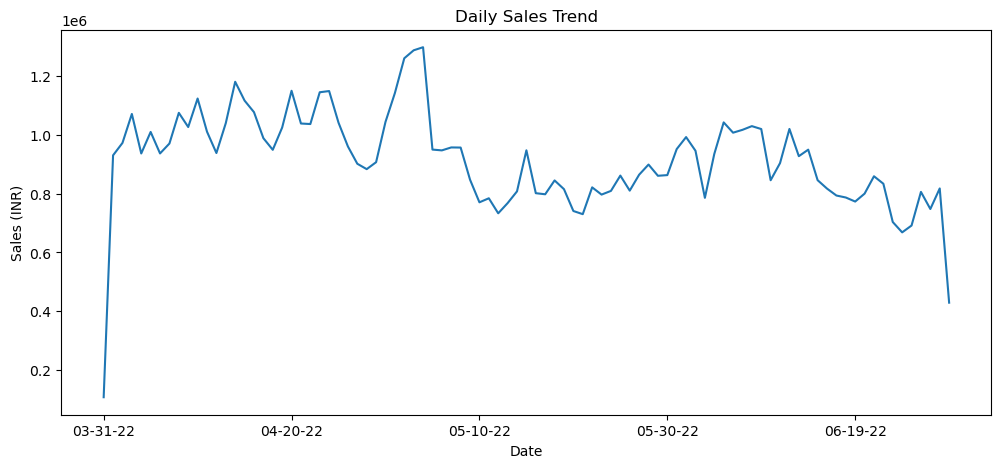

In [18]:
plt.figure(figsize=(12, 5))

daily_sales.plot()

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales (INR)")

plt.show()

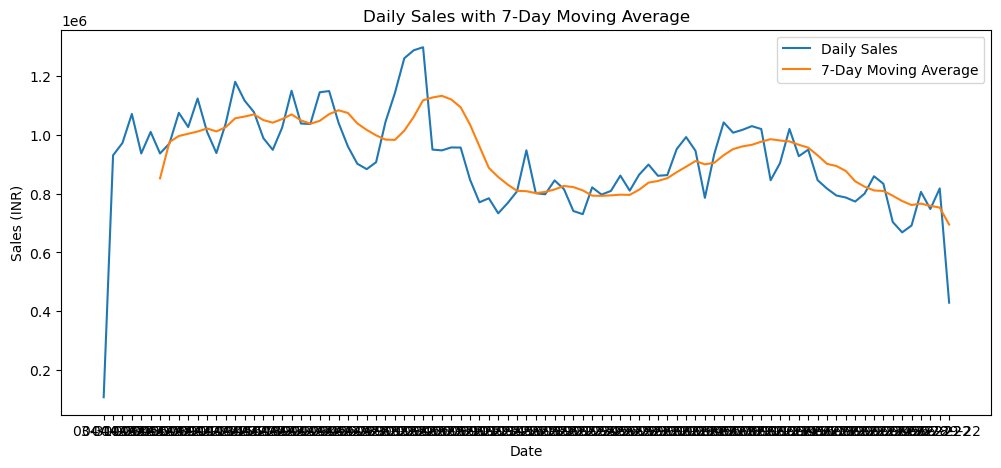

In [19]:
daily_sales_df = daily_sales.reset_index()

daily_sales_df['7_Day_Moving_Average'] = (
    daily_sales_df['Amount']
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales_df['Date'],
    daily_sales_df['Amount'],
    label='Daily Sales'
)

plt.plot(
    daily_sales_df['Date'],
    daily_sales_df['7_Day_Moving_Average'],
    label='7-Day Moving Average'
)

plt.title("Daily Sales with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales (INR)")

plt.legend()
plt.show()

In [20]:
clustering_data = df[
    ['Qty', 'Amount']
].copy()

clustering_data = clustering_data.replace(
    [np.inf, -np.inf],
    np.nan
)

clustering_data = clustering_data.dropna()

clustering_data.head()

,Qty,Amount
0,0,647.62
1,1,406.00
2,1,329.00
3,0,753.33
4,1,574.00


In [21]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    clustering_data
)

print("Data standardized successfully!")

Data standardized successfully!


In [22]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_data)
    
    inertia.append(kmeans.inertia_)

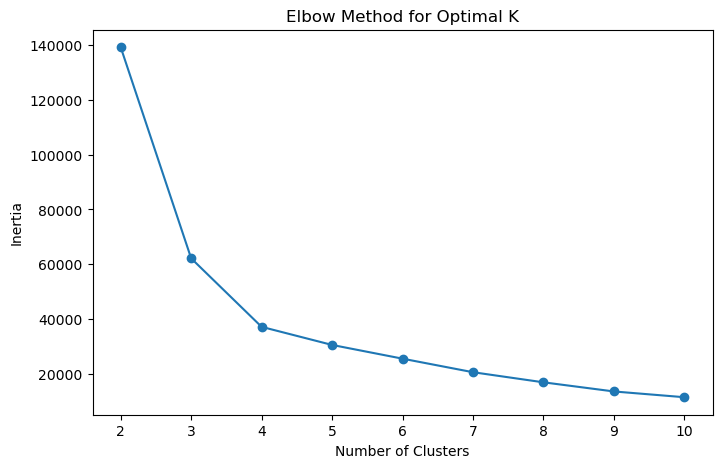

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [24]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    scaled_data
)

clustering_data['Cluster'] = clusters

clustering_data.head()

,Qty,Amount,Cluster
0,0,647.62,2
1,1,406.00,0
2,1,329.00,0
3,0,753.33,2
4,1,574.00,0


In [25]:
cluster_profile = clustering_data.groupby(
    'Cluster'
).agg({
    'Qty': ['mean', 'median'],
    'Amount': ['mean', 'median', 'count']
})

cluster_profile

Qty              Amount               
             mean median         mean  median  count
Cluster                                             
0        1.000075    1.0   419.618692   435.0  53660
1        1.021027    1.0  1169.616560  1126.0  16455
2        0.000000    0.0   610.688711   605.0  12799
3        1.002736    1.0   732.281381   735.0  46055

In [26]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    scaled_data
)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-2.036726,2.045518,2
1,-0.406307,-0.837573,0
2,-0.605909,-1.037175,0
3,-1.762701,2.319543,2
4,0.029189,-0.402078,0


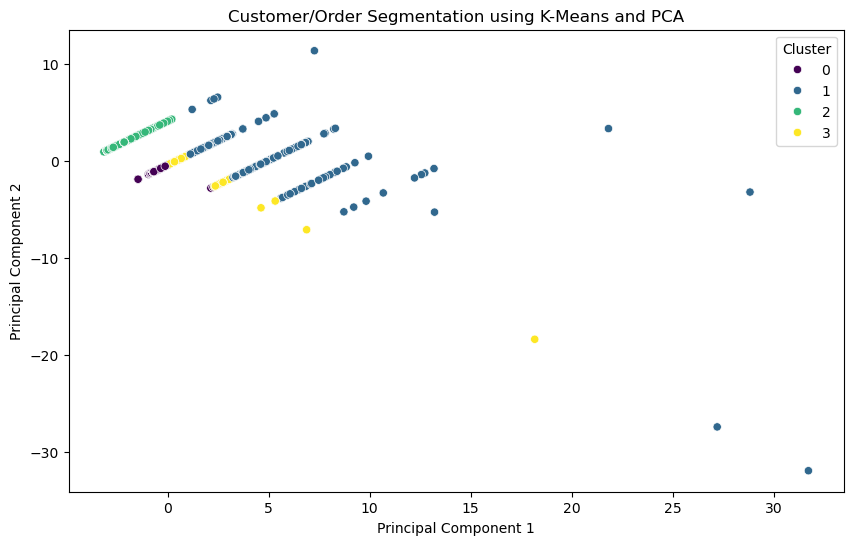

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis'
)

plt.title("Customer/Order Segmentation using K-Means and PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [28]:
df['Cancelled'] = (
    df['Status']
    .astype(str)
    .str.contains('Cancelled', case=False, na=False)
    .astype(int)
)

print(df['Cancelled'].value_counts())

Cancelled
0    110640
1     18329
Name: count, dtype: int64


In [29]:
model_data = df[
    ['Qty', 'Amount', 'Cancelled']
].copy()

model_data = model_data.replace(
    [np.inf, -np.inf],
    np.nan
)

model_data = model_data.dropna()

X = model_data[
    ['Qty', 'Amount']
]

y = model_data[
    'Cancelled'
]

print("Features:", X.columns.tolist())
print("Target: Cancelled")

Features: ['Qty', 'Amount']
Target: Cancelled


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 103175
Testing samples: 25794


In [31]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [32]:
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)

Accuracy : 0.957007171932545
Precision: 0.9911640414905878
Recall   : 0.7037643207855974


In [14]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     22129
           1       0.99      0.70      0.82      3666

    accuracy                           0.96     25795
   macro avg       0.97      0.85      0.90     25795
weighted avg       0.96      0.96      0.95     25795



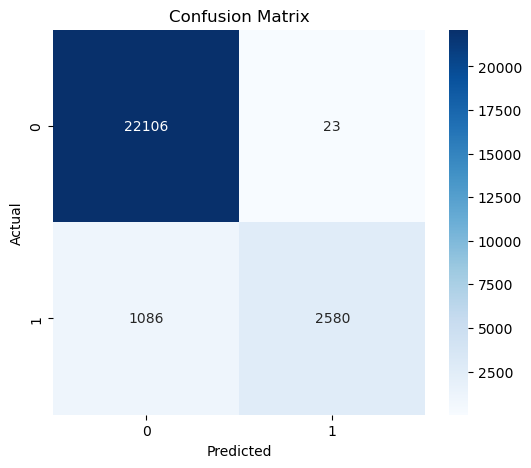

In [23]:
cm = confusion_matrix(
    y_test,
    y_pred
)

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance['Absolute_Importance'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    'Absolute_Importance',
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute_Importance
0,Qty,-7.472403,7.472403
1,Amount,0.000189,0.000189


print("""
========== TASK 4 BUSINESS INSIGHTS ==========

1. Descriptive statistics reveal the central tendency
   and variability of order quantity and order amount.

2. The t-test evaluates whether order values differ
   between Amazon and Merchant fulfilment methods.

3. The chi-square test evaluates the relationship between
   product category and order status.

4. The 95% confidence interval estimates the likely range
   of the population's average order amount.

5. Time-series analysis shows daily sales trends and
   the 7-day moving average.

6. K-Means clustering identifies four order-level segments
   based on quantity and order amount.

7. Logistic Regression predicts whether an order is cancelled
   using available numerical order features.

8. These insights can help improve sales monitoring,
   fulfilment decisions, inventory planning and
   cancellation management.
""")

In [25]:
df.to_csv(
    "task4_processed_amazon_data.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!
